In [1]:
import pandas as pd
import numpy as np
import sweetviz as sv

/home/nacho/Documents/CEIA/aprendizaje_profundo/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#Cargamos el dataset
df = pd.read_csv('dataset_compras.csv')

In [3]:
#Hacemos EDA con sweetviz
df_report = sv.analyze(df)
df_report.show_html("df_compras.html")

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)

Report df_compras.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


### Observaciones EDA
Al observar histogramas de cada feature del dataset original vemos que en las variables categóricas no hay un serio desbalance. Por otro lado, en la única variable numérica 'Purchase' hay un sesgo hacia la derecha pero no presenta outliers.

Por otro lado, los únicos faltantes corresponden a `Product Subcategory 1` (23%) y `Product Subcategory 2` (58%). Que serán imputados a 0 dando a entender que no se cuenta con informacion de los mismos. Product_Subcategory_2 sera descartada por su alta proporcion de faltantes.

Considerando que se desea definir en cierta forma al usuario para predecir su promedio de compra, las features que quizá mas relevante sean:
- Age
- Gender
- Marital Status
- City_Category
- Stay_In_Current_City_Years

Ademas de estas, seria provechoso tener una noción de las tendencias de consumo del cliente, para ello se propone crear las siguientes features
- Favourite_Product: Producto favorito (moda de Product_ID por usuario)
- Favourite_Product_Ratio: Proporcion de Favourite_Product del usuario
- Favourite_Category: Categoría favorita (moda de Product_Category por usuario)
- Favourite_Category_Ratio: Proporcion de Favourite_Category del usuario
- Favourite_Subcategory: Subcategoria favorita (moda de Product_Subcategory_1 por usuario)
- Favourite_Subcategory_Ratio: Proporcion de Favourite_Subcategory del usuario
- Purchase_Std: Desviación estándar de Purchase del usuario

Finalmente se deberá agregar el promedio de compra del cliente ya que sera nuestra variable target.

Se crea nueva tabla llamada `dataset_client.csv` que se forme a partir de `dataset_compras.csv` e incorpore todo el tratamiento mencionado  



In [4]:
client_df = df[['User_ID']].drop_duplicates().reset_index(drop=True)

purchase_mean_map = df.groupby('User_ID')['Purchase'].mean()
fav_cat_map = df.groupby('User_ID')['Product_Category'].agg(lambda x: x.mode()[0])
fav_cat_ratio_map = df.groupby('User_ID')['Product_Category'].agg(lambda x: (x == x.mode()[0]).sum() / len(x))
fav_prod_map = df.groupby('User_ID')['Product_ID'].agg(lambda x: x.mode()[0])
fav_prod_ratio_map = df.groupby('User_ID')['Product_ID'].agg(lambda x: (x == x.mode()[0]).sum() / len(x))
fav_subcat_map = df.groupby('User_ID')['Product_Subcategory_1'].agg(lambda x: x.mode()[0])
fav_subcat_ratio_map = df.groupby('User_ID')['Product_Subcategory_1'].agg(lambda x: (x == x.mode()[0]).sum() / len(x))
age_map = df.groupby('User_ID')['Age'].agg(lambda x: x.mode()[0])
gender_map = df.groupby('User_ID')['Gender'].agg(lambda x: x.mode()[0])
marital_map = df.groupby('User_ID')['Marital_Status'].agg(lambda x: x.mode()[0])
city_map = df.groupby('User_ID')['City_Category'].agg(lambda x: x.mode()[0])
stay_map = df.groupby('User_ID')['Stay_In_Current_City_Years'].agg(lambda x: x.mode()[0])
purchase_std_map = df.groupby('User_ID')['Purchase'].std()


client_df['User_Age'] = client_df['User_ID'].map(age_map)
client_df['User_Gender'] = client_df['User_ID'].map(gender_map)
client_df['User_Marital_Status'] = client_df['User_ID'].map(marital_map)
client_df['User_City_Category'] = client_df['User_ID'].map(city_map)
client_df['User_Stay'] = client_df['User_ID'].map(stay_map)
client_df['User_Favourite_Category'] = client_df['User_ID'].map(fav_cat_map)
client_df['User_Favourite_Category_Ratio'] = client_df['User_ID'].map(fav_cat_ratio_map)
client_df['User_Favourite_Product'] = client_df['User_ID'].map(fav_prod_map)
client_df['User_Favourite_Product_Ratio'] = client_df['User_ID'].map(fav_prod_ratio_map)
client_df['User_Favourite_Subcategory'] = client_df['User_ID'].map(fav_subcat_map)
client_df['User_Favourite_Subcategory_Ratio'] = client_df['User_ID'].map(fav_subcat_ratio_map)
client_df['User_Purchase_Std'] = client_df['User_ID'].map(purchase_std_map)

client_df['Purchase_Avg'] = client_df['User_ID'].map(purchase_mean_map)
client_df = client_df.drop(columns='User_ID')


In [5]:
client_df.to_csv('dataset_client.csv', index=False)
client_df.head()

,User_Age,User_Gender,User_Marital_Status,User_City_Category,User_Stay,User_Favourite_Category,User_Favourite_Category_Ratio,User_Favourite_Product,User_Favourite_Product_Ratio,User_Favourite_Subcategory,User_Favourite_Subcategory_Ratio,User_Purchase_Std,Purchase_Avg
0,46-50,F,1,B,1,3,0.142857,P00007791,0.071429,45.0,0.285714,4658.452349,6895.142857
1,36-45,M,0,A,3,12,0.142857,P00073174,0.040816,27.0,0.102041,4658.147039,4666.857143
2,36-45,M,1,A,5+,3,0.200000,P00082464,0.057143,36.0,0.085714,9486.178066,11071.771429
3,36-45,M,1,A,1,3,0.180000,P00027480,0.040000,24.0,0.080000,9423.190657,13216.360000
4,46-50,M,1,A,5+,3,0.145833,P00006469,0.041667,42.0,0.083333,8085.955697,8613.562500


In [6]:
client_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7432 entries, 0 to 7431
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   User_Age                          7432 non-null   str    
 1   User_Gender                       7432 non-null   str    
 2   User_Marital_Status               7432 non-null   int64  
 3   User_City_Category                7432 non-null   str    
 4   User_Stay                         7432 non-null   str    
 5   User_Favourite_Category           7432 non-null   int64  
 6   User_Favourite_Category_Ratio     7432 non-null   float64
 7   User_Favourite_Product            7432 non-null   str    
 8   User_Favourite_Product_Ratio      7432 non-null   float64
 9   User_Favourite_Subcategory        7432 non-null   float64
 10  User_Favourite_Subcategory_Ratio  7432 non-null   float64
 11  User_Purchase_Std                 7432 non-null   float64
 12  Purchase_Avg     

In [7]:
# Realizamos nuevamente el EDA pero con users
client_report = sv.analyze(client_df,target_feat='Purchase_Avg')
client_report.show_html("df_client.html")

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)

Report df_client.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


### Observaciones EDA

Tras realizar nuevamente el EDA observamos que no tenemos faltantes ni outliers. Ademas la distribucion de la variables categóricas sigue siendo balanceada. 

Un punto interesante es que la matriz de asociaciones de sweetviz marca relaciones entre todos los feautres y el target, indicando que posiblemente estos puedan ayudar a predecirla. 

Por ultimo se analizo la cardinalidad de las variables categóricas para decidir que tipo de encoding realizar.
- User_Age: (7) OHE
- User_Gender: (2) OHE
- User_Marital_Status: (2) OHE
- User_City_Category: (3) OHE
- User_Stay: (5) OHE
- User_Favourite_Category: (20) Target Encoding
- User_Favourite_Product: (1214) Target Encoding
- User_Favourite_Category: (33) Target Encoding

Las features de cardinalidad media-alta usaran Target Encoding, procurando ajustar con los datos de entrenamiento para no producir leakage.

Se aplicara también estandarización a las variables a las que se les produjo Target Encoding y a Purchase_Std. Las features de ratios no son escaladas ya que su rango es de 0 a 1.

In [8]:
client_df = pd.read_csv('dataset_client.csv')

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, TargetEncoder, StandardScaler
from sklearn.model_selection import train_test_split
X = client_df.drop(columns='Purchase_Avg')
y = client_df['Purchase_Avg']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.3, random_state=42)
ohe_cols = [
    'User_Age',
    'User_Gender',
    'User_Marital_Status',
    'User_City_Category',
    'User_Stay',
]
target_enc_cols = [
    'User_Favourite_Category',
    'User_Favourite_Subcategory',
    'User_Favourite_Product'
]
scale_cols = [
    'User_Purchase_Std',
]

preprocessor = ColumnTransformer(
    transformers=[ 
        ('one_hot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ohe_cols),
        ('target_enc_scaled', Pipeline([
            ('encoder', TargetEncoder(random_state=42)),
            ('scaler', StandardScaler())
        ]), target_enc_cols),
        ('scale', StandardScaler(), scale_cols)
    ],
    remainder='passthrough'
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

pipeline.set_output(transform="pandas")

pipeline.fit(X_train, y_train)
X_train = pipeline.transform(X_train)
X_test = pipeline.transform(X_test)
X_val = pipeline.transform(X_val)


/home/nacho/Documents/CEIA/aprendizaje_profundo/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


In [10]:
pd.set_option('display.max_columns', None)
X_train.head()

,one_hot__User_Age_0-17,one_hot__User_Age_18-25,one_hot__User_Age_26-35,one_hot__User_Age_36-45,one_hot__User_Age_46-50,one_hot__User_Age_51-55,one_hot__User_Age_55+,one_hot__User_Gender_F,one_hot__User_Gender_M,one_hot__User_Marital_Status_0,one_hot__User_Marital_Status_1,one_hot__User_City_Category_A,one_hot__User_City_Category_B,one_hot__User_City_Category_C,one_hot__User_Stay_1,one_hot__User_Stay_2,one_hot__User_Stay_3,one_hot__User_Stay_4,one_hot__User_Stay_5+,target_enc_scaled__User_Favourite_Category,target_enc_scaled__User_Favourite_Subcategory,target_enc_scaled__User_Favourite_Product,scale__User_Purchase_Std,remainder__User_Favourite_Category_Ratio,remainder__User_Favourite_Product_Ratio,remainder__User_Favourite_Subcategory_Ratio
1914,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.058048,1.597734,0.611271,1.624957,0.160000,0.040000,0.080000
5451,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.249753,-0.239467,-0.555644,-0.125259,0.142857,0.040816,0.122449
5604,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.058048,0.117821,0.108712,0.731047,0.150000,0.050000,0.200000
3772,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,-1.054117,-0.603412,-0.807872,0.017716,0.222222,0.055556,0.166667
7259,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,-1.094480,-0.539165,-1.709884,-1.248577,0.200000,0.100000,0.200000


### Definicion del modelo MLP
Se propone un modelo de las siguientes caracteristicas:
- 3 capas ocultas (128 neuronas, 64 neuronas, 32 neuronas)
- Funcion de activacion GeLU, con la justificacion de que la red es pequeña y los datos de entrenamiento son escasos, por los que sus perjuicios relacionados a la complejidad computacional no son significativos.
- La funcion de costo sera el RMSE, ya que tendremos un numero mas interpretable que MSE al estar en las mismas unidades que nuestra variable target, a la vez que penalizara con mas severidad que MAE a los erroes grandes. 
- Para el optimizador se utilizara Adam Mini Batch ya que suele ser mas insensible al learning rate. Se selecciona un Batch Size de 256.
- Para el learning rate se propone realizar pruebas sobre un set de validación y determinarlo de manera empírica.

In [11]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# =======================
# Configuración inicial
# =======================
torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train = torch.tensor(X_train.values, dtype=torch.float32).to(device)
X_test  = torch.tensor(X_test.values, dtype=torch.float32).to(device)
X_val  = torch.tensor(X_val.values, dtype=torch.float32).to(device)

y_train = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1).to(device)
y_test  = torch.tensor(y_test.values, dtype=torch.float32).reshape(-1, 1).to(device)
y_val  = torch.tensor(y_val.values, dtype=torch.float32).reshape(-1, 1).to(device)

input_layer_size = X_train.shape[1]



In [12]:
# Learning Rates
learning_rates = [0.5, 0.1, 1e-2, 1e-3]
batch_size = 256
epochs = 50
nn_val_results = {}

In [13]:
import copy
for lr in learning_rates:
    model = nn.Sequential(
        nn.Linear(input_layer_size, 128),
        nn.GELU(),
        nn.Linear(128, 64),
        nn.GELU(),
        nn.Linear(64, 32),
        nn.GELU(),
        nn.Linear(32, 1),
    ).to(device)

    ds = TensorDataset(X_train, y_train)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=False)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    mse_loss = nn.MSELoss()

    # =======================
    # Entrenamiento
    # =======================
    nn_val_results[lr] = {
        'train_loss_hist' : [],
        'r2_hist' : [],
        'val_loss_hist' : [],
        'model' : None,
        'best_epoch' : None
    }

    best_loss = float('inf')
    best_model_state = None
    best_epoch = None

    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for xb, yb in dl:
            yhat = model(xb)
            loss = torch.sqrt(mse_loss(yhat, yb))  # RMSE

            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
            epoch_loss += loss.item()

        # Promedio de pérdidas por época
        epoch_loss /= len(dl)
        nn_val_results[lr]['train_loss_hist'].append(epoch_loss)

        # Evaluación por época sobre Validation
        model.eval()
        with torch.no_grad():
            yhat_val = model(X_val)
            y_true_np = y_val.view(-1).cpu().numpy()
            y_pred_np = yhat_val.view(-1).cpu().numpy()
            r2 = r2_score(y_true_np, y_pred_np)
            nn_val_results[lr]['r2_hist'].append(r2)
            val_loss = torch.sqrt(mse_loss(yhat_val, y_val)).cpu().numpy()
            nn_val_results[lr]['val_loss_hist'].append(val_loss)

            if val_loss < best_loss:
                best_loss = val_loss
                best_model_state = copy.deepcopy(model.state_dict())
                best_epoch = epoch
        model.train()

    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    nn_val_results[lr]['model'] = model
    nn_val_results[lr]['best_epoch'] = best_epoch


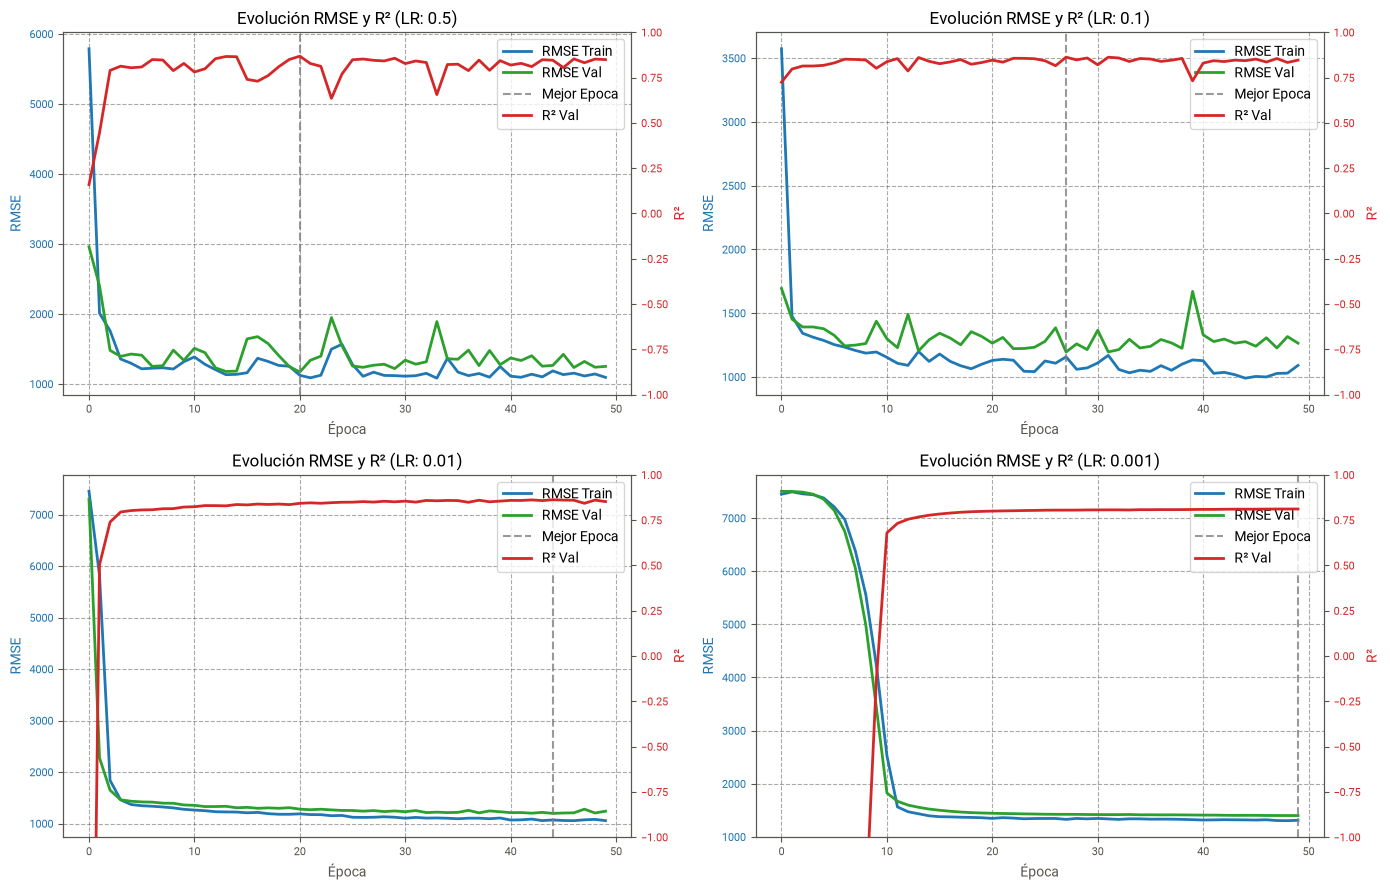

In [15]:
# Comparacion entre learning rates
fig, axs = plt.subplots(2, 2, figsize=(14, 9))

for ax1, lr in zip(axs.flat, nn_val_results.keys()):
    ax1.plot(nn_val_results[lr]['train_loss_hist'], color='tab:blue', label='RMSE Train', linewidth=2)
    ax1.plot(nn_val_results[lr]['val_loss_hist'], color='tab:green', label='RMSE Val', linewidth=2)
    
    # Agregar línea vertical en la mejor época (best_epoch)
    best_epoch = nn_val_results[lr]['best_epoch']
    ax1.axvline(x=best_epoch, color='gray', linestyle='--', label='Mejor Epoca', alpha=0.8)
    
    ax1.set_xlabel("Época")
    ax1.set_ylabel("RMSE", color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.grid(True, linestyle='--', alpha=0.5)

    ax2 = ax1.twinx()
    ax2.plot(nn_val_results[lr]['r2_hist'], color='tab:red', label='R² Val', linewidth=2)
    ax2.set_ylabel("R²", color='tab:red')
    ax2.set_ylim(-1,1)
    ax2.tick_params(axis='y', labelcolor='tab:red')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

    ax1.set_title(f"Evolución RMSE y R² (LR: {lr})")

plt.tight_layout()
plt.show()



### Eleccion de learning rate

Tras observar el comportamiento del modelo con los distintos valores, vemos como los de 0.5 y 0.1 no logran converger después de 50 épocas, mientras que los de 0.01 y 0.001 si. Ademas en estos ultimos no se observa overfitting, ya que los valores de RMSE en Train y Val se mantienen en valores similares, sin que uno mejore drásticamente mientras el otro empeora. Se selecciona el de 0.01 ya que converge a un mínimo con menor RMSE y mayor $R^2$.

/tmp/ipykernel_43469/3002716361.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


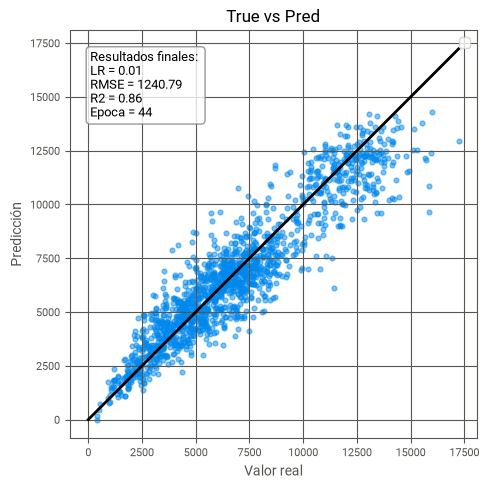

In [22]:
# Evaluación final
winner = 0.01
model = nn_val_results[winner]['model']
epoch = nn_val_results[winner]['best_epoch']
model.eval()
with torch.no_grad():
    yhat = model(X_test)
    mse = mse_loss(yhat, y_test).item()
    rmse = mse ** 0.5
    y_true_np = y_test.view(-1).cpu().numpy()
    y_pred_np = yhat.view(-1).cpu().numpy()
    r2 = r2_score(y_true_np, y_pred_np)


# Gráfica True vs Pred
plt.figure(figsize=(5,5))
plt.scatter(y_true_np, y_pred_np, s=12, alpha=0.5)
m = float(min(y_true_np.min(), y_pred_np.min()))
M = float(max(y_true_np.max(), y_pred_np.max()))
plt.plot([m, M], [m, M], linewidth=2, color="black")
plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.title("True vs Pred")
textstr = f"Resultados finales: \nLR = {winner}\nRMSE = {rmse:.2f}\nR2 = {r2:.2f}\nEpoca = {epoch}"
props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
plt.gca().text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=9.5,
            verticalalignment='top', bbox=props)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Conclusiones

A partir de registros de ventas se armo un nuevo dataset con informacion de los clientes con el fin de predecir el gasto promedio de aquellos que cuentan con pocas registros. Esto implico crear features, limpiar los datos, codificarlas, escalarlas y procurar no incurrir en data leakeage entremedio. Las features que el modelo utiliza son:
- User_Age
- User_Gender
- User_Marital_Status
- User_City_Category
- User_Stay
- User_Favourite_Category
- User_Favourite_Category_Ratio
- User_Favourite_Product
- User_Favourite_Product_Ratio
- User_Favourite_Subcategory
- User_Favourite_Subcategory_Ratio
- User_Puchase_Std
Por otro lado, la variable target es:
- Purchase_Avg

Una vez construido el dataset se armo el modelo MLP de la siguiente forma:
- 3 capas ocultas (128, 64 y 32 neuronas)
- Funcion de activacion GeLu
- Optimizador Adam Mini Batch, con batch size de 256
- Learning rate de 0.01
- Funcion de costo RMSE
- Entrenamiento de 50 epocas (mejor resultado sobre validation en epoca 44)

Las características del modelo fueron seleccionadas de forma teórica a excepción del learning rate que fue obtenido de forma empírica tras probar distintos valores sobre un set de validación.

El desempeño del modelo sobre el set de Test fue:

| Métrica | Valor |
| -------- | -------- |
| $R^2$  |  0.86 |
| RMSE  |  1240.79 |

En cuanto al valor de $R^2$ se logro superar el 0,7 sugerido como criterio de buen desempeño. Al observar el gráfico de dispersion se muestra que el modelo sigue de cierta forma la tendencia de la variable a predecir. 

Por otro lado, el valor obtenido de RMSE es difícil de estimar su significancia sin tener contexto del problema de negocio. Sin embargo, considerando que el desvió estándar de la variable a predecir es de 3300 aproximadamente, nuestro modelo predice considerablemente mejor que si solo usásemos la media.
